## 1. Data Loading and Initial Inspection


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load Dataset
from pathlib import Path

candidate_files = [
    Path("/content/drive/MyDrive/Churn_prediction.xlsx"),
    Path("/content/drive/MyDrive/churn_predict.csv"),
    Path("Churn_prediction.xlsx"),
    Path("churn_predict.csv"),
]

data_path = next((file for file in candidate_files if file.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Please place churn_predict.csv or Churn_prediction.xlsx "
        "in the notebook directory, or update candidate_files with the correct path."
    )

if data_path.suffix.lower() in [".xlsx", ".xls"]:
    df = pd.read_excel(data_path)
elif data_path.suffix.lower() == ".csv":
    df = pd.read_csv(data_path)
else:
    raise ValueError(f"Unsupported file format: {data_path.suffix}")

print(f"Loaded dataset: {data_path}")
df.head()


In [ ]:
# Initial Data Inspection
df.head(5)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,52869,0,20.0,Mobile Phone,3,7.0,E wallet,Female,4.0,4,Fashion,5,Married,3,0,26.0,5.0,16.0,NaN,229.53
1,52942,0,13.0,Computer,1,9.0,Cash on Delivery,Female,4.0,4,Fashion,3,Single,2,0,26.0,11.0,NaN,9.0,234.38
2,52972,0,16.0,Mobile Phone,3,7.0,Debit Card,Male,3.0,4,Laptop & Accessory,3,Divorced,3,0,26.0,5.0,12.0,7.0,174.07
3,53125,0,5.0,Mobile Phone,1,16.0,Debit Card,Male,3.0,4,Fashion,4,Married,3,0,26.0,2.0,2.0,9.0,231.48
4,53367,0,9.0,Mobile Phone,1,28.0,Debit Card,Female,3.0,4,Laptop & Accessory,2,Divorced,3,1,26.0,1.0,2.0,8.0,165.14


In [ ]:
df.shape


(5630, 20)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

## 2. Feature Classification


In [ ]:
# Identify ID Column
id_cols = ['CustomerID']


In [ ]:
# Numeric columns to treat as categorical
cat_manual = ["Churn", "Complain", "CityTier", "SatisfactionScore"]


In [ ]:
# Numerical variables
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [col for col in num_cols if col not in id_cols and col not in cat_manual]


In [ ]:
# Categorical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = cat_cols + [col for col in cat_manual if col in df.columns]


## 3. Data Distribution Analysis


In [ ]:
# Distribution of Numerical Variables
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Tenure,5366.0,10.189899,8.557241,0.0,2.00,9.00,16.0000,61.00
WarehouseToHome,5379.0,15.639896,8.531475,5.0,9.00,14.00,20.0000,127.00
HourSpendOnApp,5375.0,2.931535,0.721926,0.0,2.00,3.00,3.0000,5.00
NumberOfDeviceRegistered,5630.0,3.688988,1.023999,1.0,3.00,4.00,4.0000,6.00
NumberOfAddress,5630.0,4.214032,2.583586,1.0,2.00,3.00,6.0000,22.00
OrderAmountHikeFromlastYear,5365.0,15.707922,3.675485,11.0,13.00,15.00,18.0000,26.00
CouponUsed,5374.0,1.751023,1.894621,0.0,1.00,1.00,2.0000,16.00
OrderCount,5372.0,3.008004,2.939680,1.0,1.00,2.00,3.0000,16.00
DaySinceLastOrder,5323.0,4.543491,3.654433,0.0,2.00,3.00,7.0000,46.00
CashbackAmount,5630.0,177.223030,49.207036,0.0,145.77,163.28,196.3925,324.99


In [ ]:
# Skewness of Numerical Variables
df[num_cols].skew()


,0
Tenure,0.736513
WarehouseToHome,1.619154
HourSpendOnApp,-0.027213
NumberOfDeviceRegistered,-0.396969
NumberOfAddress,1.088639
OrderAmountHikeFromlastYear,0.790785
CouponUsed,2.545653
OrderCount,2.196414
DaySinceLastOrder,1.191000
CashbackAmount,1.149846


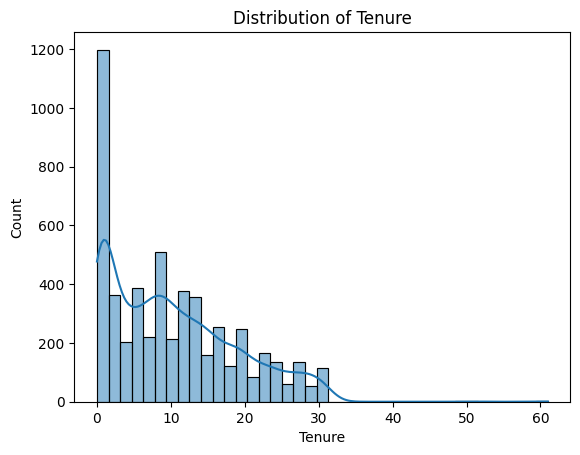

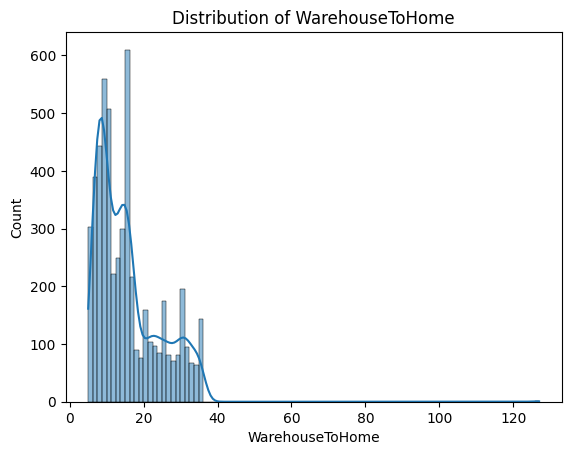

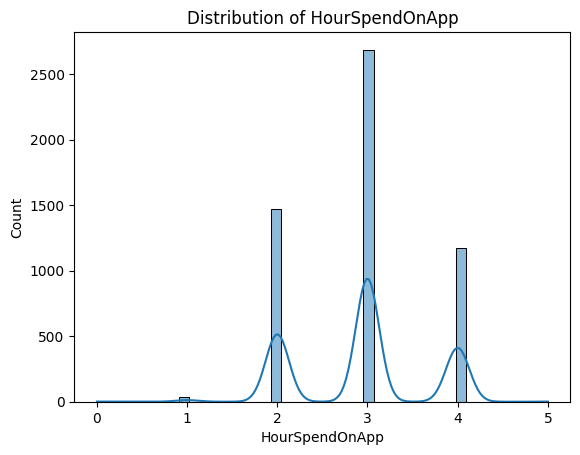

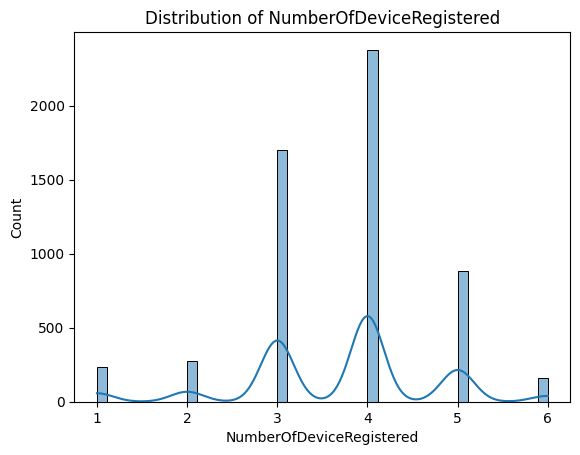

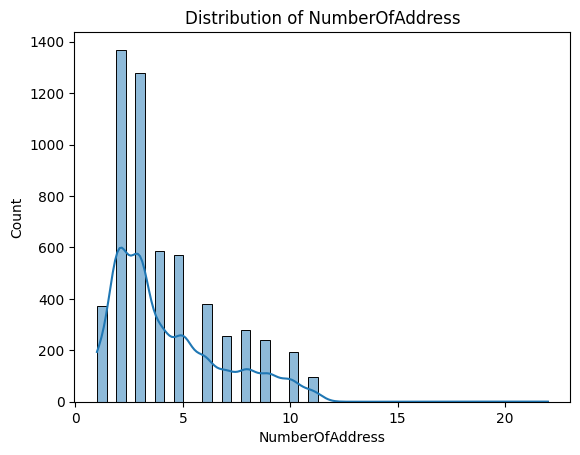

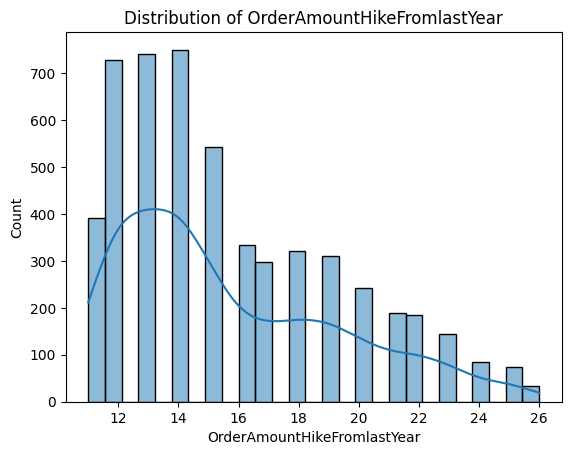

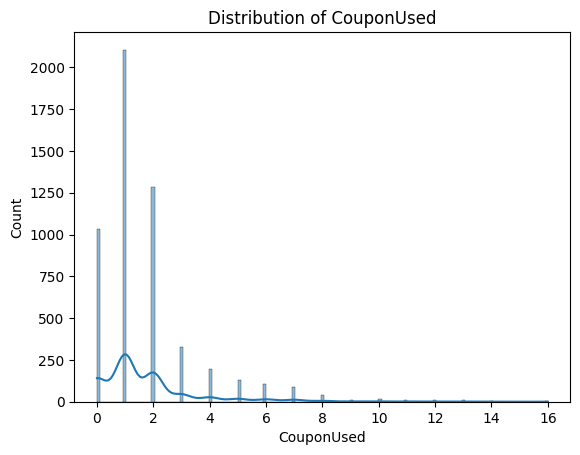

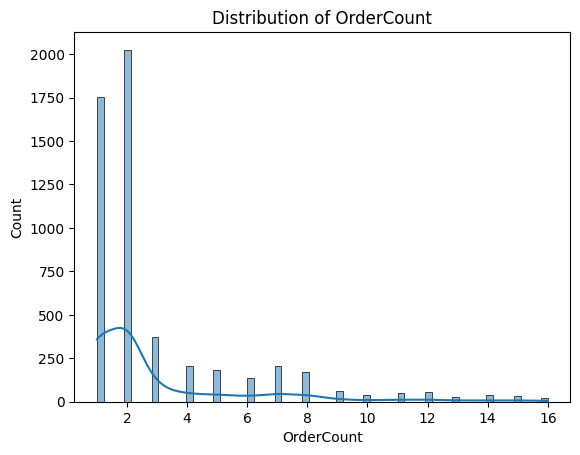

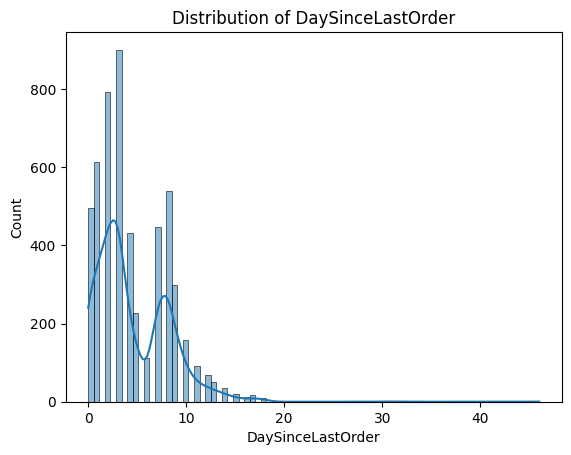

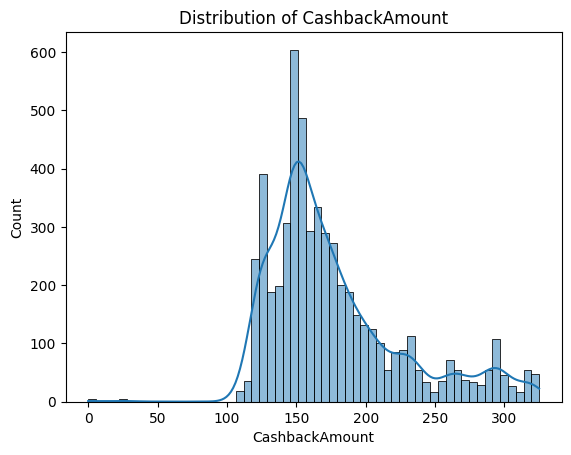

In [ ]:
for col in num_cols:
  sns.histplot(df[col], kde=True)
  plt.title(f"Distribution of {col}")
  plt.show()


In [ ]:
# Distribution of Categorical Variables
for col in cat_cols:
  print(col)

  # Count how many times each category appears
  print(df[col].value_counts())

  # Calculate the percentage of each category
  print(df[col].value_counts(normalize=True) * 100)


PreferredLoginDevice
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredLoginDevice
Mobile Phone    49.111901
Computer        29.023091
Phone           21.865009
Name: proportion, dtype: float64
PreferredPaymentMode
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          41.101243
Credit Card         26.660746
E wallet            10.905861
UPI                  7.353464
COD                  6.483126
CC                   4.849023
Cash on Delivery     2.646536
Name: proportion, dtype: float64
Gender
Gender
Male      3384
Female    2246
Name: count, dtype: int64
Gender
Male      60.106572
Female    39.893428
Name: proportion, dtype: float64
PreferedOrderCat
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone       

## 4. Missing Values and Data Cleaning


In [ ]:
df.isnull().mean() * 100


,0
CustomerID,0.000000
Churn,0.000000
Tenure,4.689165
PreferredLoginDevice,0.000000
CityTier,0.000000
WarehouseToHome,4.458259
PreferredPaymentMode,0.000000
Gender,0.000000
HourSpendOnApp,4.529307
NumberOfDeviceRegistered,0.000000


In [ ]:
# Fill missing values in numeric columns with median
for col in num_cols:
  df[col] = df[col].fillna(df[col].median())


In [ ]:
# Fill missing values in categorical columns with mode
for col in cat_cols:
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
# Inconsistent Catrgory Handling
for col in cat_cols:
  print(col)
  print(df[col].unique())


PreferredLoginDevice
['Mobile Phone' 'Computer' 'Phone']
PreferredPaymentMode
['E wallet' 'Cash on Delivery' 'Debit Card' 'UPI' 'Credit Card' 'COD' 'CC']
Gender
['Female' 'Male']
PreferedOrderCat
['Fashion' 'Laptop & Accessory' 'Mobile Phone' 'Grocery' 'Mobile' 'Others']
MaritalStatus
['Married' 'Single' 'Divorced']
Churn
[0 1]
Complain
[0 1]
CityTier
[3 1 2]
SatisfactionScore
[5 3 4 2 1]


In [ ]:
# Standardize inconsistent category labels
if "PreferredLoginDevice" in df.columns:
    df["PreferredLoginDevice"] = df["PreferredLoginDevice"].replace({
        "Phone": "Mobile Phone",
        "Mobile": "Mobile Phone",
    })

if "PreferredPaymentMode" in df.columns:
    df["PreferredPaymentMode"] = df["PreferredPaymentMode"].replace({
        "COD": "Cash on Delivery",
        "CC": "Credit Card",
    })

order_cat_col = None
for possible_col in ["PreferedOrderCat", "PreferredOrderCat"]:
    if possible_col in df.columns:
        order_cat_col = possible_col
        break

if order_cat_col is not None:
    df[order_cat_col] = df[order_cat_col].replace({
        "Mobile": "Mobile Phone",
    })


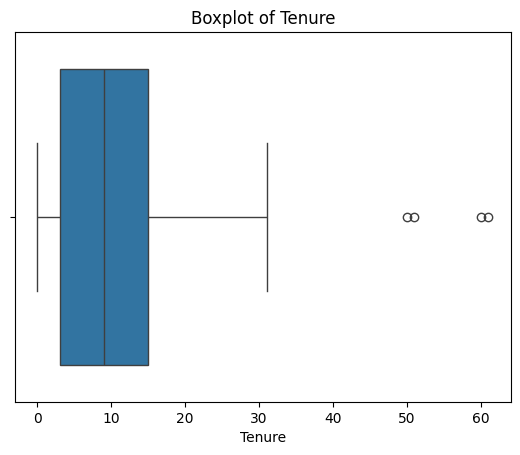

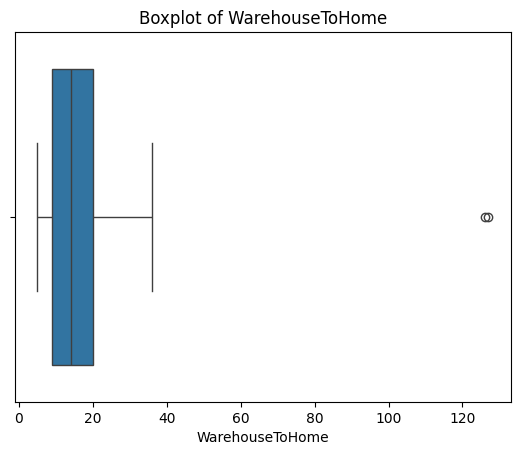

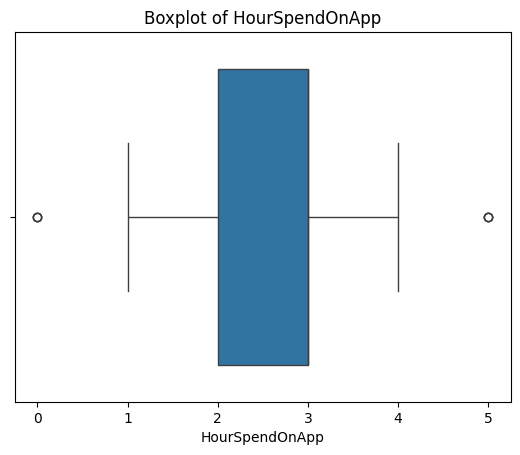

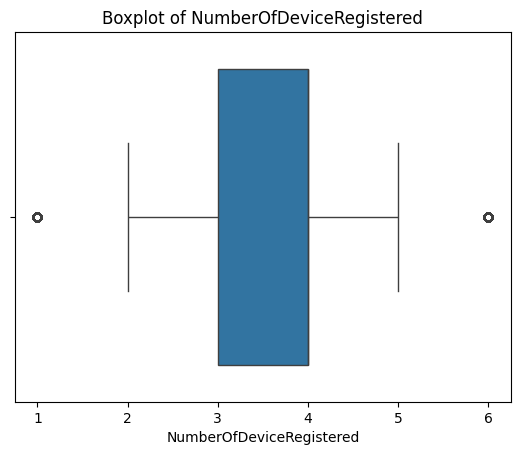

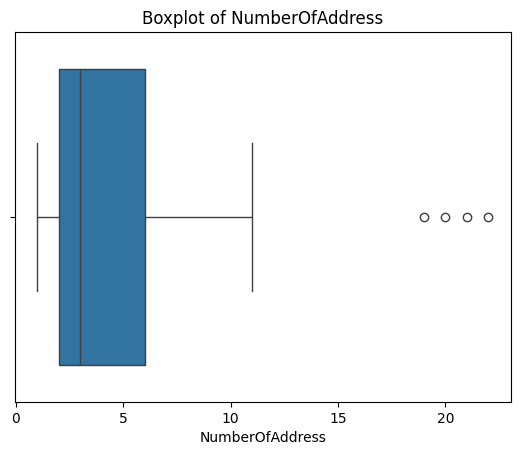

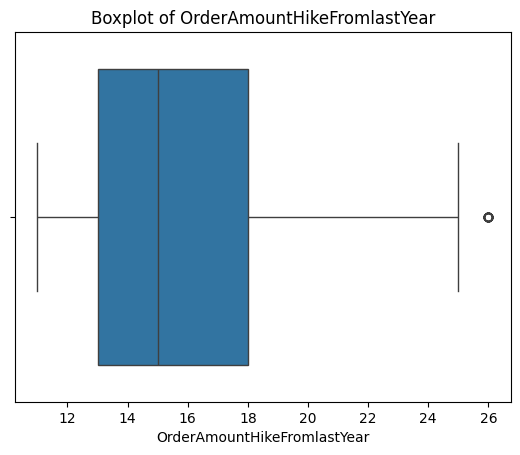

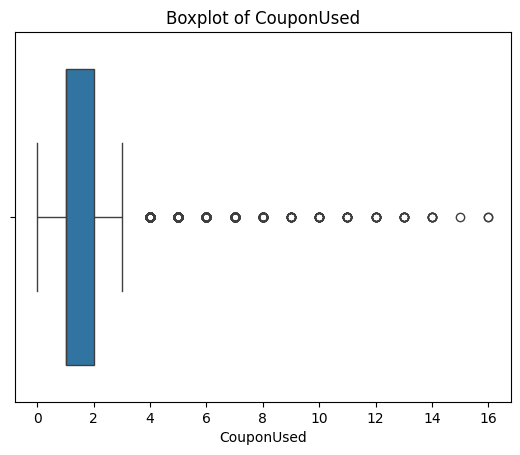

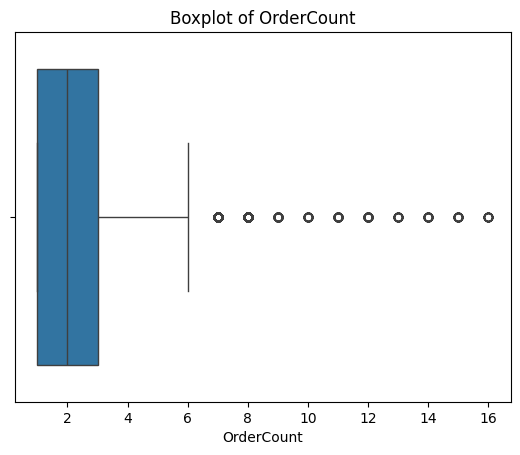

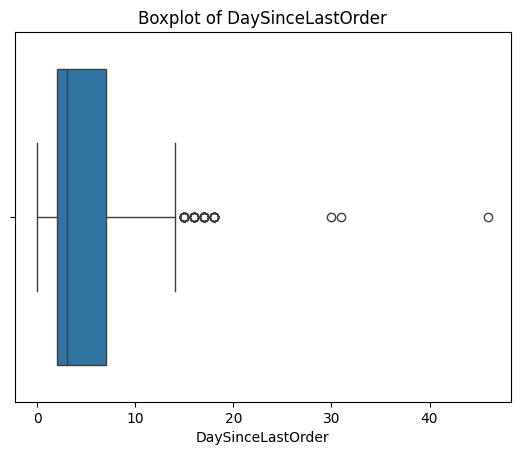

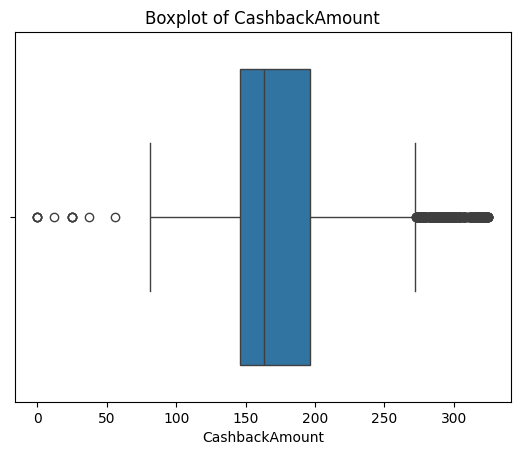

In [ ]:
# Outlier Detection
for col in num_cols:
  sns.boxplot(x=df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()


## 5. Relationship Between Features and Churn


In [ ]:
# Numerical Features vs Churn
df.groupby("Churn")[num_cols].mean()


,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,NumberOfAddress,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
Churn,,,,,,,,,,
0,11.404528,15.305639,2.928663,3.639257,4.162965,15.686032,1.718069,2.992952,4.709739,180.635203
1,3.859705,16.856540,2.964135,3.934599,4.466245,15.618143,1.710970,2.808017,3.222574,160.370928


In [ ]:
df.groupby("Churn")[num_cols].median()


,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,NumberOfAddress,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
Churn,,,,,,,,,,
0,10.0,14.0,3.0,4.0,3.0,15.0,1.0,2.0,3.0,166.115
1,1.0,14.0,3.0,4.0,3.0,15.0,1.0,2.0,2.5,149.660


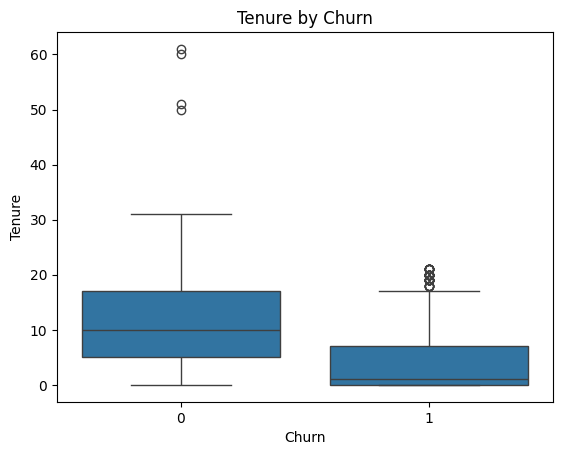

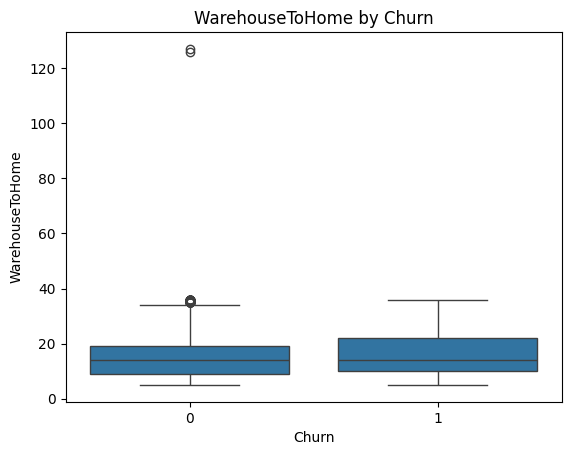

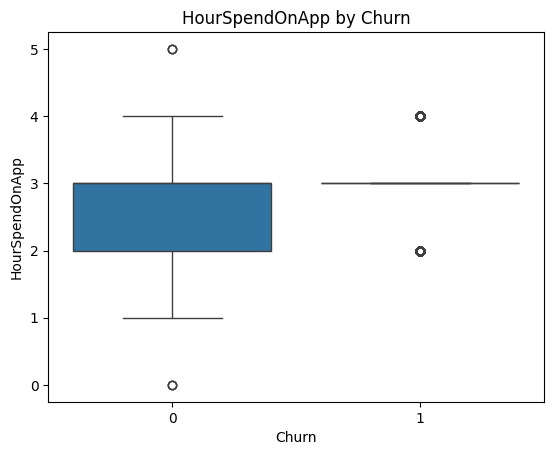

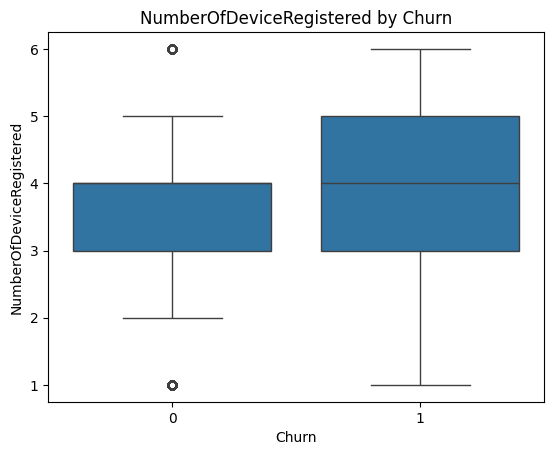

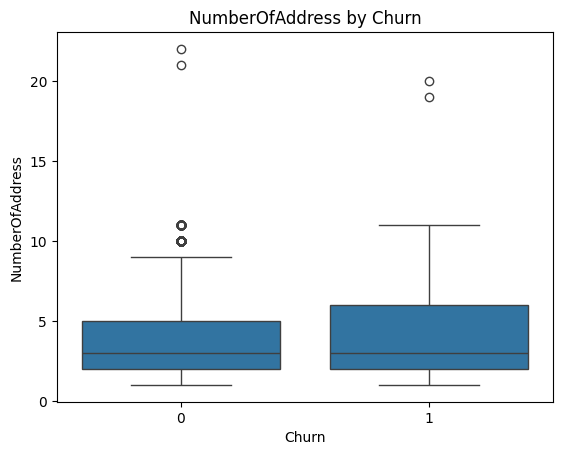

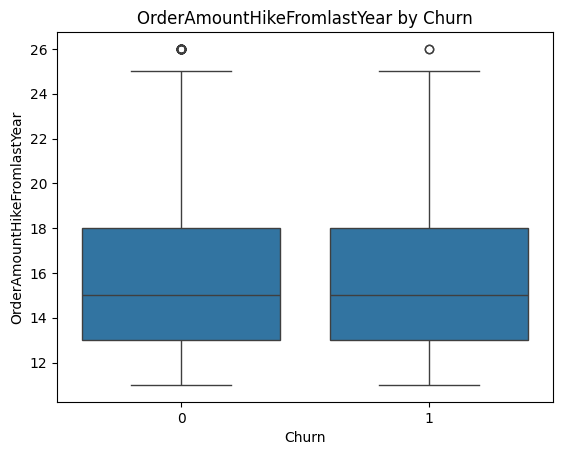

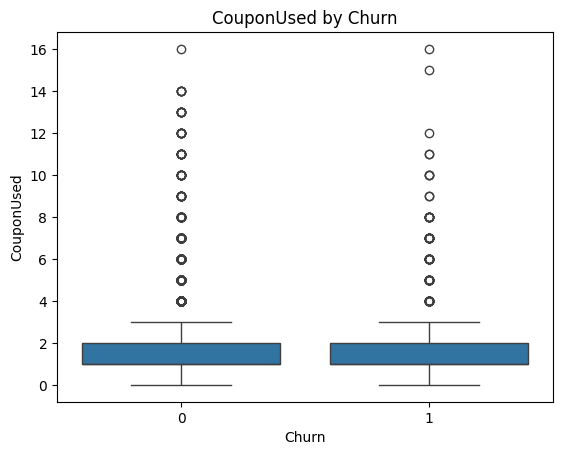

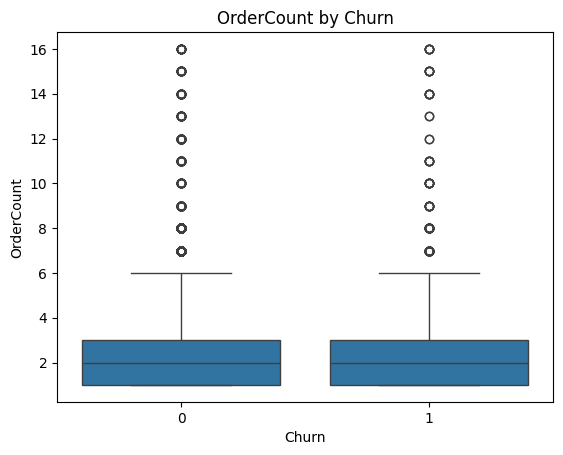

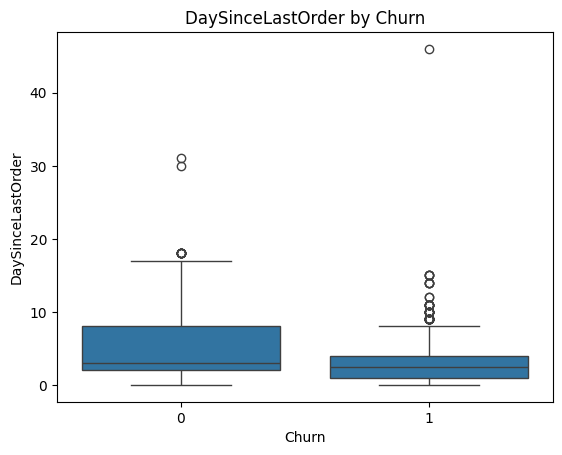

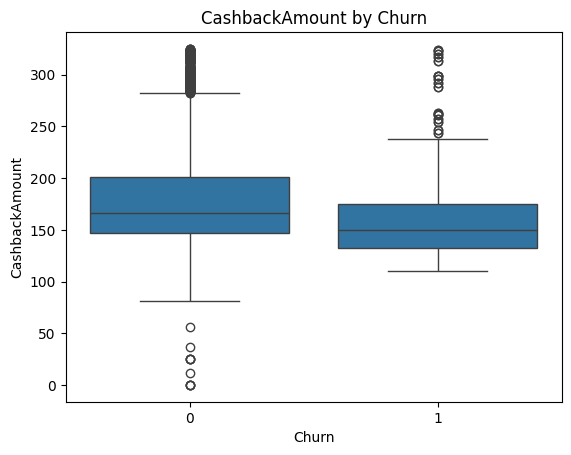

In [ ]:
for col in num_cols:
  sns.boxplot(data=df, x="Churn", y=col)
  plt.title(f"{col} by Churn")
  plt.show()


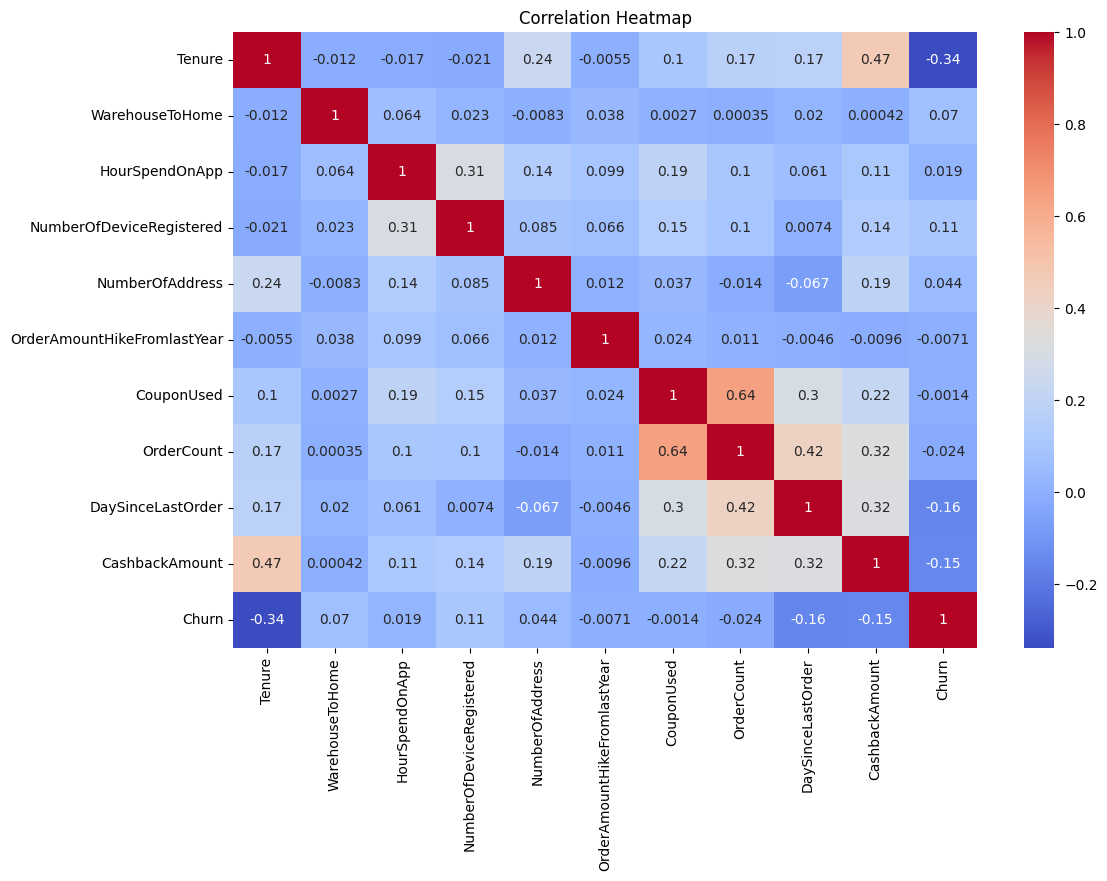

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols + ["Churn"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Churn Rate by Category
for col in cat_cols:
  if col != "Churn":
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    print(churn_rate)


PreferredLoginDevice
Computer        0.198286
Mobile Phone    0.156156
Name: Churn, dtype: float64
PreferredPaymentMode
Cash on Delivery    0.249027
E wallet            0.228013
UPI                 0.173913
Debit Card          0.153846
Credit Card         0.142052
Name: Churn, dtype: float64
Gender
Male      0.177305
Female    0.154942
Name: Churn, dtype: float64
PreferedOrderCat
Mobile Phone          0.274038
Fashion               0.154964
Laptop & Accessory    0.102439
Others                0.075758
Grocery               0.048780
Name: Churn, dtype: float64
MaritalStatus
Single      0.267261
Divorced    0.146226
Married     0.115204
Name: Churn, dtype: float64
Complain
1    0.316708
0    0.109290
Name: Churn, dtype: float64
CityTier
3    0.213705
2    0.198347
1    0.145117
Name: Churn, dtype: float64
SatisfactionScore
5    0.238267
3    0.171967
4    0.171322
2    0.126280
1    0.115120
Name: Churn, dtype: float64


## 6. Churned User Behavior Analysis


Based on the descriptive statistics and churn comparison, churn users show several clear behavioral patterns.
*   First, churned users tend to have shorter tenure, meaning that new customers are more likely to leave the platform. This is supported by the negative correlation between Tenure and Churn.
*   Second, customers who raised complaints are more likely to churn, suggesting that customer dissatisfaction or unresolved service issues may be an important reason for leaving
*   Third, churned users tend to receive lower cashback amounts, which may indicate that promotional benefits or loyalty incentives are not strong enough for this group
In addition, **WarehouseToHome** has a weak positive relationship with **Churn**, meaning that customers who live farther from the warehouse may have a slightly higher churn risk, possibly due to longer delivery time or lower delivery convenience. Overall, churned users are likely to be newer customers, customers with complaints, customers receiving lower cashback, and customers who may experience delivery inconvenience.


## 7. Business Recommendations


The company should focus on retaining high-risk users, especially new customers and customers with complaints. Since shorter-tenure customers are more likely to churn, welcome vouchers, free shipping or cashback for the first few orders can help increase retention.
The company should also improve complaint handling by responding faster and offering compensation, such as discount codes or cashback after resolving issues.
For customers living farther from the warehouse, the company can improve delivery time estimation, optimize warehouse allocation, or provide shipping discounts to reduce delivery-related dissatisfaction.


## 8. Supervised Learning


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    balanced_accuracy_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

import joblib
from pathlib import Path


In [ ]:
# One-hot encoding
model_cat_cols = [col for col in cat_cols if col != 'Churn']
df_encoded = pd.get_dummies(df, columns=model_cat_cols, drop_first=True, dtype=int)


In [ ]:
# Define features and target
x = df_encoded.drop(columns=["CustomerID", "Churn"])
y = df_encoded["Churn"]


In [ ]:
#Train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
# Scale features for Logistic Regression
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [ ]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(x_train_scaled, y_train)

y_test_pred = log_model.predict(x_test_scaled)

print("Logistic Regression")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


Logistic Regression
Balanced Accuracy: 0.8053699955015745
[[749 187]
 [ 36 154]]
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       936
           1       0.45      0.81      0.58       190

    accuracy                           0.80      1126
   macro avg       0.70      0.81      0.73      1126
weighted avg       0.87      0.80      0.82      1126



In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")

rf_model.fit(x_train, y_train)

y_test_pred = rf_model.predict(x_test)

print("Random Forest")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))


Random Forest
Balanced Accuracy: 0.9215080971659919
[[927   9]
 [ 28 162]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       936
           1       0.95      0.85      0.90       190

    accuracy                           0.97      1126
   macro avg       0.96      0.92      0.94      1126
weighted avg       0.97      0.97      0.97      1126



In [ ]:
# Hyperparameter Tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='balanced_accuracy')

grid_search.fit(x_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
# Evaluate best Random Forest model
best_rf_model = grid_search.best_estimator_

y_pred_best_rf = best_rf_model.predict(x_test)

print("Tuned Random Forest")
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_best_rf))
print(confusion_matrix(y_test, y_pred_best_rf))
print(classification_report(y_test, y_pred_best_rf))


Tuned Random Forest
Balanced Accuracy: 0.956174089068826
[[918  18]
 [ 13 177]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       936
           1       0.91      0.93      0.92       190

    accuracy                           0.97      1126
   macro avg       0.95      0.96      0.95      1126
weighted avg       0.97      0.97      0.97      1126



### 8.1 Advanced Model Evaluation

The churn dataset is imbalanced, so balanced accuracy alone is not enough. This section compares models using multiple metrics and focuses especially on recall for churned customers.


In [ ]:
# Create folder for exported result images
result_dir = Path("images")
result_dir.mkdir(exist_ok=True)


In [ ]:
# Compare supervised learning models using multiple metrics
model_predictions = {
    "Logistic Regression": {
        "y_pred": log_model.predict(x_test_scaled),
        "y_proba": log_model.predict_proba(x_test_scaled)[:, 1],
    },
    "Random Forest": {
        "y_pred": rf_model.predict(x_test),
        "y_proba": rf_model.predict_proba(x_test)[:, 1],
    },
    "Tuned Random Forest": {
        "y_pred": best_rf_model.predict(x_test),
        "y_proba": best_rf_model.predict_proba(x_test)[:, 1],
    },
}

model_results = []

for model_name, pred_data in model_predictions.items():
    y_pred = pred_data["y_pred"]
    y_proba = pred_data["y_proba"]

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision (Churn=1)": precision_score(y_test, y_pred),
        "Recall (Churn=1)": recall_score(y_test, y_pred),
        "F1-score (Churn=1)": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "PR-AUC": average_precision_score(y_test, y_proba),
    })

model_results_df = pd.DataFrame(model_results).sort_values("Balanced Accuracy", ascending=False)
model_results_df


In [ ]:
# Visualize model comparison
plot_df = model_results_df.set_index("Model")[[
    "Balanced Accuracy",
    "Recall (Churn=1)",
    "F1-score (Churn=1)",
    "ROC-AUC",
    "PR-AUC",
]]

plt.figure(figsize=(12, 6))
sns.heatmap(plot_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.savefig(result_dir / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Confusion matrix for the best model
ConfusionMatrixDisplay.from_estimator(
    best_rf_model,
    x_test,
    y_test,
    display_labels=["Not Churn", "Churn"],
    cmap="Blues",
)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.tight_layout()
plt.savefig(result_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y_test, y_pred_best_rf, target_names=["Not Churn", "Churn"]))


In [ ]:
# ROC and Precision-Recall curves for the best model
y_proba_best_rf = best_rf_model.predict_proba(x_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, y_proba_best_rf, ax=axes[0])
axes[0].set_title("ROC Curve - Tuned Random Forest")

PrecisionRecallDisplay.from_predictions(y_test, y_proba_best_rf, ax=axes[1])
axes[1].set_title("Precision-Recall Curve - Tuned Random Forest")

plt.tight_layout()
plt.savefig(result_dir / "roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 8.2 Threshold Tuning

The default classification threshold is `0.5`. For churn prediction, the business may prefer a lower threshold to catch more high-risk customers, even if it creates more false positives.


In [ ]:
# Test multiple probability thresholds for churn prediction
thresholds = np.arange(0.10, 0.91, 0.05)
threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_best_rf >= threshold).astype(int)
    threshold_results.append({
        "Threshold": threshold,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred_threshold),
        "Precision (Churn=1)": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall (Churn=1)": recall_score(y_test, y_pred_threshold),
        "F1-score (Churn=1)": f1_score(y_test, y_pred_threshold),
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df.sort_values("F1-score (Churn=1)", ascending=False).head(10)


In [ ]:
# Plot threshold trade-off
plt.figure(figsize=(10, 6))
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Precision (Churn=1)"], marker="o", label="Precision")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Recall (Churn=1)"], marker="o", label="Recall")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["F1-score (Churn=1)"], marker="o", label="F1-score")
plt.plot(threshold_results_df["Threshold"], threshold_results_df["Balanced Accuracy"], marker="o", label="Balanced Accuracy")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning for Churn Prediction")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(result_dir / "threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Recommended threshold based on best F1-score for churn class
best_threshold_row = threshold_results_df.loc[threshold_results_df["F1-score (Churn=1)"].idxmax()]
best_threshold = best_threshold_row["Threshold"]

print("Recommended threshold based on best F1-score:")
print(best_threshold_row)

# Business note:
# If the company wants to catch more churners, choose a lower threshold with higher recall.
# If the company wants fewer false alarms, choose a higher threshold with higher precision.


### 8.3 Feature Importance

Feature importance helps explain which variables are most useful for predicting churn and supports business recommendations.


In [ ]:
# Feature importance from the tuned Random Forest model
feature_importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_rf_model.feature_importances_,
}).sort_values("Importance", ascending=False)

feature_importance_df.head(20)


In [ ]:
# Visualize top feature importances
plt.figure(figsize=(10, 8))
sns.barplot(
    data=feature_importance_df.head(20),
    x="Importance",
    y="Feature",
    palette="viridis",
)
plt.title("Top 20 Feature Importances - Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(result_dir / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Save best model and preprocessing artifacts for future use
joblib.dump(best_rf_model, "tuned_random_forest_churn_model.pkl")
joblib.dump(scaler, "standard_scaler.pkl")

print("Saved tuned_random_forest_churn_model.pkl")
print("Saved standard_scaler.pkl")


## 9. Unsupervised Learning


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [ ]:
churn_df = df[df["Churn"] == 1].copy()

churn_df.shape


(948, 20)

In [ ]:
# Drop ID and target column
cluster_data = churn_df.drop(columns=["CustomerID","Churn"])


In [ ]:
# Encode categorical variables
cluster_data_encoded = pd.get_dummies(
    cluster_data,
    drop_first=True,
    dtype=int
)


In [ ]:
# Scale data before Kmeans
scaler = StandardScaler()

cluster_data_scaled = scaler.fit_transform(cluster_data_encoded)


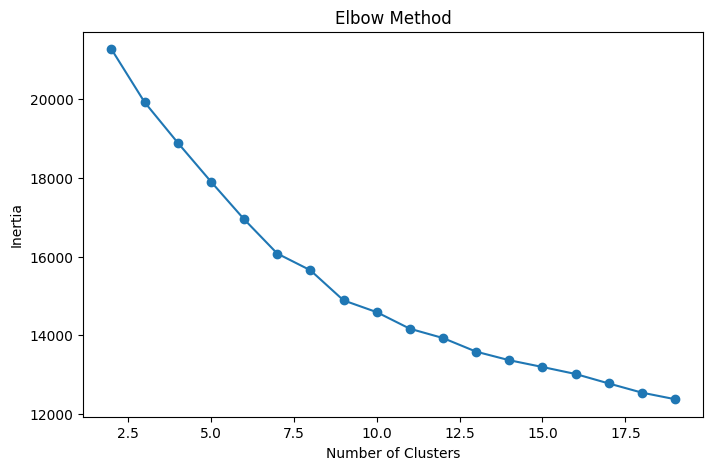

In [ ]:
# Elbow Method
inertia = []

K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_data_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [ ]:
optimal_k = 7

# Train KMeans
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
churn_df["Segment"] = kmeans.fit_predict(cluster_data_scaled)


### 9.1 Cluster Validation

The clustering result is evaluated using silhouette score and visualized with PCA to check whether churned customer segments show separation in lower-dimensional space.


In [ ]:
# Evaluate clustering quality
silhouette_avg = silhouette_score(cluster_data_scaled, churn_df["Segment"])
print(f"Silhouette Score for k={optimal_k}: {silhouette_avg:.4f}")


In [ ]:
# PCA visualization of churned customer segments
pca = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(cluster_data_scaled)

pca_df = pd.DataFrame({
    "PCA1": cluster_pca[:, 0],
    "PCA2": cluster_pca[:, 1],
    "Segment": churn_df["Segment"].astype(str),
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="Segment", palette="tab10", alpha=0.7)
plt.title("PCA Visualization of Churned Customer Segments")
plt.tight_layout()
plt.savefig(result_dir / "churned_customer_segments_pca.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Percentage of churn customers by segment
churn_df["Segment"].value_counts(normalize=True) * 100


,proportion
Segment,
3,31.645570
1,23.523207
2,19.514768
4,13.502110
6,7.594937
5,2.109705
0,2.109705


In [ ]:
# Compare numerical features across churned user segments

num_cols_cluster = churn_df.select_dtypes(include=np.number).columns.tolist()
num_cols_cluster = [
    col for col in num_cols_cluster
    if col not in ["CustomerID", "Churn", "Segment"]
]

churn_df.groupby("Segment")[num_cols_cluster].mean().T


Segment,0,1,2,3,4,5,6
Tenure,13.500,5.134529,2.005405,3.763333,3.015625,8.100,2.722222
CityTier,1.800,2.130045,1.270270,1.393333,3.000000,2.600,1.833333
WarehouseToHome,10.500,18.977578,15.945946,14.560000,19.406250,18.500,18.972222
HourSpendOnApp,2.900,3.035874,2.902703,3.020000,2.890625,2.700,2.888889
NumberOfDeviceRegistered,4.300,4.062780,3.918919,3.890000,3.953125,3.100,3.861111
SatisfactionScore,3.500,3.493274,3.302703,3.426667,3.328125,3.300,3.250000
NumberOfAddress,4.700,5.237668,4.227027,4.153333,3.765625,6.300,4.666667
Complain,0.600,0.381166,0.600000,0.560000,0.593750,0.600,0.611111
OrderAmountHikeFromlastYear,15.100,15.883408,15.237838,16.016667,15.062500,13.900,15.722222
CouponUsed,3.850,2.313901,1.275676,1.330000,1.500000,3.700,1.777778


In [ ]:
# # Compare categorical features across churned user segments
cat_cols_cluster = churn_df.select_dtypes(include="object").columns.tolist()

for col in cat_cols_cluster:
    print(f"\n{col}")
    print(pd.crosstab(churn_df["Segment"], churn_df[col], normalize="index") * 100)



PreferredLoginDevice
PreferredLoginDevice   Computer  Mobile Phone
Segment                                      
0                      0.000000    100.000000
1                     24.663677     75.336323
2                     36.756757     63.243243
3                     40.333333     59.666667
4                     28.125000     71.875000
5                     80.000000     20.000000
6                     38.888889     61.111111

PreferredPaymentMode
PreferredPaymentMode  Cash on Delivery  Credit Card  Debit Card  E wallet  \
Segment                                                                     
0                            20.000000    20.000000   20.000000      40.0   
1                            14.349776    39.461883   46.188341       0.0   
2                            13.513514    86.486486    0.000000       0.0   
3                            22.333333     0.000000   77.666667       0.0   
4                             0.000000     0.000000    0.000000     100.0   
5  

### 9.2 Segment Profiling and Business Actions

This section summarizes each churned customer segment and maps it to a practical retention or win-back action.


In [ ]:
# Segment size summary
segment_size = (
    churn_df["Segment"]
    .value_counts()
    .sort_index()
    .rename_axis("Segment")
    .reset_index(name="Customer Count")
)
segment_size["Customer Share"] = segment_size["Customer Count"] / segment_size["Customer Count"].sum()
segment_size


In [ ]:
# Numerical segment profile
segment_numeric_profile = churn_df.groupby("Segment")[num_cols_cluster].mean().round(2)
segment_numeric_profile


In [ ]:
# Top categorical value per segment
segment_categorical_profile = []

for segment, segment_df in churn_df.groupby("Segment"):
    row = {"Segment": segment}
    for col in cat_cols_cluster:
        top_value = segment_df[col].mode(dropna=True)
        row[col] = top_value.iloc[0] if len(top_value) > 0 else np.nan
    segment_categorical_profile.append(row)

segment_categorical_profile_df = pd.DataFrame(segment_categorical_profile).sort_values("Segment")
segment_categorical_profile_df


In [ ]:
# Business action template by segment
segment_action_plan = pd.DataFrame({
    "Segment": sorted(churn_df["Segment"].unique()),
    "Segment Name": [
        "New / Low Engagement Churners",
        "Complaint-Driven Churners",
        "Distance-Sensitive Churners",
        "Promotion-Sensitive Churners",
        "High-Value Lost Customers",
        "Low Activity Churners",
        "Mixed Risk Churners",
    ][:churn_df["Segment"].nunique()],
    "Recommended Action": [
        "Send welcome voucher and onboarding campaign",
        "Prioritize service recovery and compensation voucher",
        "Offer delivery support or delivery fee incentive",
        "Send personalized coupon or cashback campaign",
        "Create premium win-back offer based on past behavior",
        "Use reactivation campaign with limited-time incentive",
        "Monitor behavior and test personalized retention offer",
    ][:churn_df["Segment"].nunique()],
})

segment_action_plan


## 10. Final Business Interpretation

The supervised learning result shows that the tuned Random Forest model is the strongest churn prediction model among the tested approaches. It should be used to identify high-risk customers before they leave.

The threshold tuning section helps the business choose a churn probability threshold based on strategy:

- Use a lower threshold if the company wants to catch more potential churners.
- Use a higher threshold if the company wants to reduce false alarms and promotion cost.

The feature importance section explains which customer behaviors are most related to churn risk. These features should be used to design retention triggers and customer monitoring rules.

The clustering section shows that churned customers are not one homogeneous group. Different segments require different actions such as onboarding vouchers, complaint recovery, delivery support, personalized cashback, or premium win-back offers.
